# [自编码器](https://arxiv.org/abs/2201.03898)


在训练CNN时，一个问题是我们需要大量的标注数据。以图像分类为例，我们需要将图像分成不同的类别，这通常需要手动完成。

然而，我们可能希望使用原始（未标注）数据来训练CNN特征提取器，这种方法称为**自监督学习**。在这种情况下，我们将使用训练图像作为网络的输入和输出。**自动编码器**的核心思想是，我们会有一个**编码器网络**，将输入图像转换为某种**潜在空间**（通常是一个较小尺寸的向量），然后通过**解码器网络**，其目标是重建原始图像。

由于我们训练自动编码器的目的是尽可能捕捉原始图像中的信息以实现准确的重建，网络会尝试找到输入图像的最佳**嵌入**来捕捉其含义。

![自动编码器示意图](../../../../../lessons/4-ComputerVision/09-Autoencoders/images/autoencoder_schema.jpg)

> 图片来源：[Keras博客](https://blog.keras.io/building-autoencoders-in-keras.html)

让我们为MNIST创建最简单的自动编码器吧！


In [1]:
!pip install tqdm


Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple, https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 2.3 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [1]:
import torch
import torchvision
import matplotlib.pyplot as plt
from torchvision import transforms
from torch import nn
from torch import optim
from tqdm import tqdm
import numpy as np
import torch.nn.functional as F
torch.manual_seed(42)
np.random.seed(42)

定义训练参数并检查GPU是否可用：


In [2]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
train_size = 0.9
lr = 1e-3
eps = 1e-8
batch_size = 256
epochs = 30

以下函数将加载MNIST数据集并应用指定的转换。它还会将其拆分为训练/测试数据集。


In [3]:
def mnist(train_part, transform=None):
    dataset = torchvision.datasets.MNIST('.', download=True, transform=transform)
    train_part = int(train_part * len(dataset))
    train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_part, len(dataset) - train_part])
    return train_dataset, test_dataset

In [4]:

def fashionmnist(train_part, transform=None):
    dataset = torchvision.datasets.FashionMNIST('.', download=True, transform=transform)
    train_part = int(train_part * len(dataset))
    train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_part, len(dataset) - train_part])
    return train_dataset, test_dataset

现在让我们加载数据集并为训练和测试定义数据加载器：


In [5]:
transform = transforms.Compose([transforms.ToTensor()])

train_dataset, test_dataset = mnist(train_size, transform)

train_dataloader = torch.utils.data.DataLoader(train_dataset, drop_last=True, batch_size=batch_size, shuffle=True)
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=1, shuffle=False)
dataloaders = (train_dataloader, test_dataloader)

In [6]:
def plotn(n, data, noisy=False, super_res=None):
    fig, ax = plt.subplots(1, n)
    for i, z in enumerate(data):
        if i == n:
            break
        #z[0]是图像，z[1]是标签
        preprocess = z[0].reshape(1, 28, 28) if z[0].shape[1] == 28 else z[0].reshape(1, 14, 14) if z[0].shape[1] == 14 else z[0]
        if super_res is not None:
            #下采样，降低分辨率
            _transform = transforms.Resize((int(preprocess.shape[1] / super_res), int(preprocess.shape[2] / super_res)))
            #resize不会动通道数
            preprocess = _transform(preprocess)

        if noisy:
            shapes = list(preprocess.shape)
            preprocess += noisify(shapes)
            #用noisify生成噪声

        ax[i].imshow(preprocess[0])
    plt.show()

In [7]:
def noisify(shapes):
    return np.random.normal(loc=0.5, scale=0.3, size=shapes)

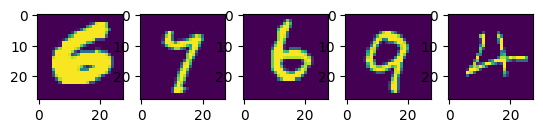

In [8]:
plotn(5, train_dataset)

In [8]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=(3, 3), padding='same')
        #我去，还有这个操作，不用手动计算了
        self.maxpool1 = nn.MaxPool2d(kernel_size=(2, 2))
        self.conv2 = nn.Conv2d(16, 8, kernel_size=(3, 3), padding='same')
        self.maxpool2 = nn.MaxPool2d(kernel_size=(2, 2))
        self.conv3 = nn.Conv2d(8, 8, kernel_size=(3, 3), padding='same')
        self.maxpool3 = nn.MaxPool2d(kernel_size=(2, 2), padding=(1, 1))
        self.relu = nn.ReLU()
        # self.flat=nn.Flatten()
        # self.linear=nn.Linear(8*4*4,16)
        #淦忘记关掉了

    def forward(self, input):
        # print(input.shape)
        hidden1 = self.maxpool1(self.relu(self.conv1(input)))
        # print(hidden1.shape)
        hidden2 = self.maxpool2(self.relu(self.conv2(hidden1)))
        # print(hidden2.shape)
        encoded = self.maxpool3(self.relu(self.conv3(hidden2)))
        # print(encoded.shape)
        # yasuo=self.linear(self.flat(encoded))
        # print(yasuo.shape)
        return encoded

In [9]:
class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear=nn.Linear(4,8*4*4)
        self.conv1 = nn.Conv2d(8, 8, kernel_size=(3, 3), padding='same')
        self.upsample1 = nn.Upsample(scale_factor=(2, 2))
        self.conv2 = nn.Conv2d(8, 8, kernel_size=(3, 3), padding='same')
        self.upsample2 = nn.Upsample(scale_factor=(2, 2))
        self.conv3 = nn.Conv2d(8, 16, kernel_size=(3, 3))
        self.upsample3 = nn.Upsample(scale_factor=(2, 2))
        self.conv4 = nn.Conv2d(16, 1, kernel_size=(3, 3), padding='same')
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, input):
        zhankai = self.linear(input)
        zhankai=zhankai.view(-1,8,4,4)
        hidden1 = self.upsample1(self.relu(self.conv1(input)))
        hidden2 = self.upsample2(self.relu(self.conv2(hidden1)))
        hidden3 = self.upsample3(self.relu(self.conv3(hidden2)))
        decoded = self.sigmoid(self.conv4(hidden3))
        return decoded

In [10]:
class AutoEncoder(nn.Module):
    def __init__(self, super_resolution=False):
        super().__init__()
        if not super_resolution:
            self.encoder = Encoder()
        else:
            self.encoder = SuperResolutionEncoder()
        self.decoder = Decoder()

    def forward(self, input):
        encoded = self.encoder(input)
        decoded = self.decoder(encoded)
        return decoded

In [44]:
model = AutoEncoder().to(device)
optimizer = optim.Adam(model.parameters(), lr=lr, eps=eps)
loss_fn = nn.BCELoss()

In [17]:


def train(dataloaders, model, loss_fn, optimizer, epochs, device, noisy=None, super_res=None):
    tqdm_iter = tqdm(range(epochs))
    train_dataloader, test_dataloader = dataloaders[0], dataloaders[1]
    best_loss=float('inf')
    patience=5
    counter=0
    for epoch in tqdm_iter:
        model.train()
        train_loss = 0.0
        test_loss = 0.0

        for batch in train_dataloader:
            imgs, labels = batch
            shapes = list(imgs.shape)

            if super_res is not None:
                shapes[2], shapes[3] = int(shapes[2] / super_res), int(shapes[3] / super_res)
                _transform = transforms.Resize((shapes[2], shapes[3]))
                imgs_transformed = _transform(imgs)
                imgs_transformed = imgs_transformed.to(device)

            imgs = imgs.to(device)
            labels = labels.to(device)
    
            if noisy is not None:
                noisy_tensor = noisy[0]
            else:
                noisy_tensor = torch.zeros(tuple(shapes)).to(device)

            if super_res is None:
                imgs_noisy = imgs + noisy_tensor
            else:
                imgs_noisy = imgs_transformed + noisy_tensor

            imgs_noisy = torch.clamp(imgs_noisy, 0., 1.)

            preds = model(imgs_noisy)
            loss = loss_fn(preds, imgs)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        model.eval()
        with torch.no_grad():
            for batch in test_dataloader:
                imgs, labels = batch
                shapes = list(imgs.shape)
                
                if super_res is not None:
                    shapes[2], shapes[3] = int(shapes[2] / super_res), int(shapes[3] / super_res)
                    _transform = transforms.Resize((shapes[2], shapes[3]))
                    imgs_transformed = _transform(imgs)
                    imgs_transformed = imgs_transformed.to(device)


                imgs = imgs.to(device)
                labels = labels.to(device)

                if noisy is not None:
                    test_noisy_tensor = noisy[1]
                else:
                    test_noisy_tensor = torch.zeros(tuple(shapes)).to(device)

                if super_res is None:
                    imgs_noisy = imgs + test_noisy_tensor
                else:
                    imgs_noisy = imgs_transformed + test_noisy_tensor

                imgs_noisy = torch.clamp(imgs_noisy, 0., 1.)

                preds = model(imgs_noisy)
                loss = loss_fn(preds, imgs)

                test_loss += loss.item()

        train_loss /= len(train_dataloader)
        test_loss /= len(test_dataloader)
        
        tqdm_dct = {'train loss:': train_loss, 'test loss:': test_loss}
        tqdm_iter.set_postfix(tqdm_dct, refresh=True)
        tqdm_iter.refresh()
        if epoch%5==0:
            plot_chaosheng()
        if test_loss<best_loss:
            best_loss=test_loss
        else:
            counter+=1
            if counter>=patience:
                print("early stop!")
                break

NameError: name 'number_list' is not defined

In [ ]:
train(dataloaders, model, loss_fn, optimizer, 10, device)

In [ ]:
def plot_show_progress(test_dataset):
    model.eval()
    predictions = []
    name=[]
    plots = 10
    for i, data in enumerate(test_dataset):
        if i == plots:
            break
        predictions.append(model(data[0].to(device).unsqueeze(0)).detach().cpu())
        name.append(data[1])
    plotn(plots, test_dataset)
    print(name)
    plotn(plots, predictions)

> **任务 1**：尝试使用非常小的潜在向量大小（例如 2）来训练自动编码器，并绘制与不同数字对应的点。*提示：在卷积部分之后使用全连接的密集层，将向量大小减少到所需值。*

> **任务 2**：从不同的数字开始，获取它们的潜在空间表示，观察在潜在空间中添加一些噪声对生成数字的影响。


提取

In [14]:
number_list=[]
for i in range(10):
    member=0
    number_list.append([])
    for number in train_dataset:
        if number[1]==i:
            member+=1
            number_list[i].append(number[0])
        if member==10:
            break

In [ ]:
model.eval()
import numpy
for i in range(10):
    prediction=[]
    print(f"number: {i}")
    for img in number_list[i]:
        v=(model.encoder((img.to(device).unsqueeze(0))).detach().cpu())
        noisy=noisify(v.shape)
        noise_torch = torch.from_numpy(noisy).to(dtype=v.dtype)*3 # 转为 float32
        y=(v+noise_torch)
        prediction.append(model.decoder((y.to(device))).detach().cpu())
    plotn(10,prediction)

## 去噪

自编码器可以被有效地用来从图像中去除噪声。为了训练一个去噪器，我们将从无噪声的图像开始，并人为地向它们添加噪声。然后，我们将带有噪声的图像作为输入，无噪声的图像作为输出，输入到自编码器中。

让我们看看这在 MNIST 数据集上的效果如何：


In [ ]:
plotn(5, train_dataset, noisy=True)

In [130]:
model = AutoEncoder().to(device)
optimizer = optim.Adam(model.parameters(), lr=lr, eps=eps)
loss_fn = nn.BCELoss()

In [120]:
noisy_tensor = torch.FloatTensor(noisify([256, 1, 28, 28])).to(device)
test_noisy_tensor = torch.FloatTensor(noisify([1, 1, 28, 28])).to(device)
noisy_tensors = (noisy_tensor, test_noisy_tensor)

In [ ]:
train(dataloaders, model, loss_fn, optimizer, 100, device, noisy=noisy_tensors)

In [ ]:

def plot_noise_clear(test_dataset):
    model.eval()
    predictions = []
    pic=[]
    noise = []
    plots = 10
    for i, data in enumerate(test_dataset):
        if i == plots:
            break
        shapes = data[0].shape
        pic.append(data[0])
        noisy_data = data[0] + test_noisy_tensor[0].detach().cpu()
        noise.append(noisy_data)
        predictions.append(model(noisy_data.to(device).unsqueeze(0)).detach().cpu())
    plotn(plots,pic)
    plotn(plots, noise)
    plotn(plots, predictions)
plot_noise_clear(test_dataset)

> **练习：** 观察在MNIST数字上训练的去噪器如何处理不同的图像。作为一个例子，你可以使用[Fashion MNIST](https://pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html#torchvision.datasets.FashionMNIST)数据集，它具有相同的图像尺寸。请注意，去噪器仅在与其训练时相同类型的图像上效果良好（即输入数据的概率分布相同）。


## 超分辨率

与去噪器类似，我们可以训练自动编码器来提高图像的分辨率。为了训练超分辨率网络，我们将从高分辨率图像开始，并自动将其缩小以生成网络输入。然后，我们将小尺寸图像作为输入，高分辨率图像作为输出，输入到自动编码器中。

为此，让我们在训练时将图像缩小到14x14。


In [ ]:
super_res_koeff = 2
plotn(5, train_dataset, super_res=super_res_koeff)

In [14]:
class SuperResolutionEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=(3, 3), padding='same')
        self.maxpool1 = nn.MaxPool2d(kernel_size=(2, 2))
        self.conv2 = nn.Conv2d(16, 8, kernel_size=(3, 3), padding='same')
        self.maxpool2 = nn.MaxPool2d(kernel_size=(2, 2), padding=(1, 1))
        self.relu = nn.ReLU()

    def forward(self, input):
        hidden1 = self.maxpool1(self.relu(self.conv1(input)))
        encoded = self.maxpool2(self.relu(self.conv2(hidden1)))
        return encoded

In [15]:
model = AutoEncoder(super_resolution=True).to(device)
optimizer = optim.Adam(model.parameters(), lr=lr, eps=eps)
loss_fn = nn.BCELoss()

In [ ]:
train(dataloaders, model, loss_fn, optimizer, epochs, device, super_res=2.0)

In [18]:
def plot_chaosheng():
    model.eval()
    predictions = []
    plots = 5
    shapes = test_dataset[0][0].shape

    for i, data in enumerate(test_dataset):
        if i == plots:
            break
        _transform = transforms.Resize((int(shapes[1] / super_res_koeff), int(shapes[2] / super_res_koeff)))
        predictions.append(model(_transform(data[0]).to(device).unsqueeze(0)).detach().cpu())
    plotn(plots, test_dataset, super_res=super_res_koeff)
    plotn(plots, predictions)

> **练习**: 尝试在 [CIFAR-10](https://pytorch.org/vision/stable/generated/torchvision.datasets.CIFAR10.html) 上训练超分辨率网络，实现2倍和4倍的上采样。使用噪声作为4倍上采样模型的输入，并观察结果。


# [变分自编码器 (VAE)](https://arxiv.org/abs/1906.02691)

传统的自编码器通过某种方式降低输入数据的维度，从而提取输入图像的重要特征。然而，潜在向量往往缺乏明确的意义。换句话说，以 MNIST 数据集为例，想要弄清楚哪些数字对应于不同的潜在向量并不是一件容易的事，因为相近的潜在向量不一定对应于相同的数字。

另一方面，为了训练*生成*模型，理解潜在空间是更有帮助的。这一想法引出了**变分自编码器**（VAE）。

VAE 是一种能够学习预测潜在参数的*统计分布*（即所谓的**潜在分布**）的自编码器。例如，我们可以假设潜在向量服从分布 $N(\mathrm{z\_mean},e^{\mathrm{z\_log}})$，其中 $\mathrm{z\_mean}, \mathrm{z\_log} \in\mathbb{R}^d$。VAE 的编码器学习预测这些参数，然后解码器从该分布中随机采样一个向量来重建对象。

总结如下：

 * 从输入向量中，我们预测 `z_mean` 和 `z_log`（我们预测的是标准差的对数，而不是标准差本身）
 * 我们从分布 $N(\mathrm{z\_mean},e^{\mathrm{z\_log\_sigma}})$ 中采样一个向量 `sample(z_val in code)`
 * 解码器尝试使用 `sample` 作为输入向量来解码原始图像

 <img src="images/vae.png" width="50%">

 > 图片来源于 [Isaak Dykeman 的这篇博客文章](https://ijdykeman.github.io/ml/2016/12/21/cvae.html)


In [61]:
class VAEEncoder(nn.Module):
    def __init__(self, device):
        super().__init__()
        self.intermediate_dim = 8*4*4
        self.latent_dim = 4
        # self.linear = nn.Linear(784, self.intermediate_dim)
        self.z_mean = nn.Linear(self.intermediate_dim, self.latent_dim)
        self.z_log = nn.Linear(self.intermediate_dim, self.latent_dim)
        self.relu = nn.ReLU()
        self.device = device
        
        self.conv1 = nn.Conv2d(1, 16, kernel_size=(3, 3), padding='same')
        #我去，还有这个操作，不用手动计算了
        self.maxpool1 = nn.MaxPool2d(kernel_size=(2, 2))
        self.conv2 = nn.Conv2d(16, 8, kernel_size=(3, 3), padding='same')
        self.maxpool2 = nn.MaxPool2d(kernel_size=(2, 2))
        self.conv3 = nn.Conv2d(8, 8, kernel_size=(3, 3), padding='same')
        self.maxpool3 = nn.MaxPool2d(kernel_size=(2, 2), padding=(1, 1))
        self.flatten=nn.Flatten()
    def forward(self, input):
        bs = input.shape[0]

#         hidden = self.relu(self.linear(input))
#         z_mean = self.z_mean(hidden)
#         z_log = self.z_log(hidden)

#         eps = torch.FloatTensor(np.random.normal(size=(bs, self.latent_dim))).to(device)
#         z_val = z_mean + torch.exp(z_log) * eps
        hidden1=self.maxpool1(self.relu(self.conv1(input)))
        hidden2=self.maxpool2(self.relu(self.conv2(hidden1)))
        hidden3=self.maxpool3(self.relu(self.conv3(hidden2)))
        flat=self.flatten(hidden3)
        z_mean=self.z_mean(flat)
        z_log=self.z_log(flat)
        eps = torch.FloatTensor(np.random.normal(size=(bs, self.latent_dim))).to(device)
        z_val = z_mean + torch.exp(z_log) * eps
        
        return z_mean, z_log, z_val

In [62]:
class VAEDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.intermediate_dim = 8*4*4
        self.latent_dim = 4
        self.linear = nn.Linear(self.latent_dim, self.intermediate_dim)
        self.output = nn.Linear(self.intermediate_dim, 784)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        
        self.conv1 = nn.Conv2d(8, 8, kernel_size=(3, 3), padding='same')
        self.upsample1 = nn.Upsample(scale_factor=(2, 2))
        self.conv2 = nn.Conv2d(8, 8, kernel_size=(3, 3), padding='same')
        self.upsample2 = nn.Upsample(scale_factor=(2, 2))
        self.conv3 = nn.Conv2d(8, 16, kernel_size=(3, 3))
        self.upsample3 = nn.Upsample(scale_factor=(2, 2))
        self.conv4 = nn.Conv2d(16, 1, kernel_size=(3, 3), padding='same')
        

    def forward(self, input):
        hidden = self.linear(input)
        hidden=hidden.view(-1,8,4,4)
        
        # decoded = self.sigmoid(self.output(hidden))
        hidden1 = self.upsample1(self.relu(self.conv1(hidden)))
        hidden2 = self.upsample2(self.relu(self.conv2(hidden1)))
        hidden3 = self.upsample3(self.relu(self.conv3(hidden2)))
        decoded = self.sigmoid(self.conv4(hidden3))
        return decoded

In [63]:
class VAEAutoEncoder(nn.Module):
    def __init__(self, device):
        super().__init__()
        self.encoder = VAEEncoder(device)
        self.decoder = VAEDecoder()
        self.z_vals = None

    def forward(self, input):
        bs, c, h, w = input.shape[0], input.shape[1], input.shape[2], input.shape[3]
        # input = input.view(bs, -1)
        encoded = self.encoder(input)
        self.z_vals = encoded
        decoded = self.decoder(encoded[2])
        return decoded
    
    def get_zvals(self):
        return self.z_vals

变分自编码器使用由两部分组成的复杂损失函数：
* **重建损失** 是一种损失函数，用于衡量重建图像与目标图像的接近程度（可以是均方误差 MSE）。它与普通自编码器中的损失函数相同。
* **KL 损失**，确保潜在变量分布接近正态分布。它基于 [Kullback-Leibler 散度](https://www.countbayesie.com/blog/2017/5/9/kullback-leibler-divergence-explained) 的概念——一种用于估计两个统计分布相似程度的度量方法。


In [64]:
def vae_loss(preds, targets, z_vals):
    mse = nn.MSELoss()
    reconstruction_loss = mse(preds, targets) * 784.0
    temp = 1.0 + z_vals[1] - torch.square(z_vals[0]) - torch.exp(z_vals[1])
    kl_loss = -0.5 * torch.sum(temp, axis=-1)
    return torch.mean(reconstruction_loss + kl_loss)

In [65]:
model = VAEAutoEncoder(device).to(device)
optimizer = optim.RMSprop(model.parameters(), lr=lr, eps=eps)

In [66]:
def train_vae(dataloaders, model, optimizer, epochs, device):
    tqdm_iter = tqdm(range(epochs))
    train_dataloader, test_dataloader = dataloaders[0], dataloaders[1]

    for epoch in tqdm_iter:
        model.train()
        train_loss = 0.0
        test_loss = 0.0

        for batch in train_dataloader:
            imgs, labels = batch
            imgs = imgs.to(device)
            labels = labels.to(device)

            preds = model(imgs)
            z_vals = model.get_zvals()
            loss = vae_loss(preds, imgs, z_vals)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        model.eval()
        with torch.no_grad():
            for batch in test_dataloader:
                imgs, labels = batch
                imgs = imgs.to(device)
                labels = labels.to(device)

                preds = model(imgs)
                z_vals = model.get_zvals()
                loss = vae_loss(preds, imgs, z_vals)

                test_loss += loss.item()

        train_loss /= len(train_dataloader)
        test_loss /= len(test_dataloader)

        tqdm_dct = {'train loss:': train_loss, 'test loss:': test_loss}
        tqdm_iter.set_postfix(tqdm_dct, refresh=True)
        tqdm_iter.refresh()
        
        
        
        model.eval()
        predictions = []
        plots = 5
        for i, data in enumerate(test_dataset):
            if i == plots:
                break
            predictions.append(model(data[0].to(device).unsqueeze(0)).view(1, 28, 28).detach().cpu())
        plotn(plots, test_dataset)
        plotn(plots, predictions)

In [ ]:
train_vae(dataloaders, model, optimizer, 16, device)

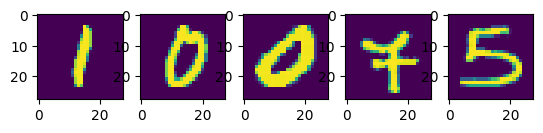

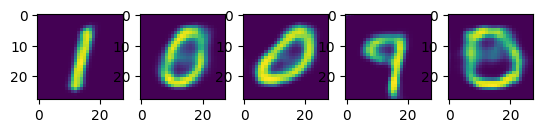

In [69]:
model.eval()
predictions = []
plots = 5
for i, data in enumerate(test_dataset):
    if i == plots:
        break
    predictions.append(model(data[0].to(device).unsqueeze(0)).view(1, 28, 28).detach().cpu())
plotn(plots, test_dataset)
plotn(plots, predictions)

> **任务**: 在我们的样本中，我们已经训练了全连接VAE。现在从上面的传统自动编码器中提取CNN，并创建基于CNN的VAE。


# [对抗自编码器 (AAE)](https://arxiv.org/abs/1511.05644)


对抗自编码器（Adversarial Auto-Encoders）是生成对抗网络（Generative Adversarial Networks）和变分自编码器（Variational Auto-Encoders）的**结合**。

编码器将作为生成器，判别器将学习区分编码器输出的真实图像和生成的图像。编码器的输出是一个分布，解码器将尝试从这个输出中解码图像。

在这种方法中，我们有**三个损失函数**：来自GAN的生成器损失、判别器损失，以及来自VAE的重构损失。

 <img src="images/aae.png" width="50%">

 > 图片来源于[这篇博客文章](https://blog.paperspace.com/adversarial-autoencoders-with-pytorch/)，作者为Felipe Ducau


In [70]:
class AAEEncoder(nn.Module):
    def __init__(self, input_dim, inter_dim, latent_dim):
        super().__init__()
        self.linear1 = nn.Linear(input_dim, inter_dim)
        self.linear2 = nn.Linear(inter_dim, inter_dim)
        self.linear3 = nn.Linear(inter_dim, inter_dim)
        self.linear4 = nn.Linear(inter_dim, latent_dim)
        self.relu = nn.ReLU()
        
    def forward(self, input):
        hidden1 = self.relu(self.linear1(input))
        hidden2 = self.relu(self.linear2(hidden1))
        hidden3 = self.relu(self.linear3(hidden2))
        encoded = self.linear4(hidden3)
        return encoded

In [71]:
class AAEDecoder(nn.Module):
    def __init__(self, latent_dim, inter_dim, output_dim):
        super().__init__()
        self.linear1 = nn.Linear(latent_dim, inter_dim)
        self.linear2 = nn.Linear(inter_dim, inter_dim)
        self.linear3 = nn.Linear(inter_dim, inter_dim)
        self.linear4 = nn.Linear(inter_dim, output_dim)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, input):
        hidden1 = self.relu(self.linear1(input))
        hidden2 = self.relu(self.linear2(hidden1))
        hidden3 = self.relu(self.linear3(hidden2))
        decoded = self.sigmoid(self.linear4(hidden3))
        return decoded

In [72]:
class AAEDiscriminator(nn.Module):
    def __init__(self, latent_dim, inter_dim):
        super().__init__()
        self.latent_dim = latent_dim
        self.inter_dim = inter_dim
        self.linear1 = nn.Linear(latent_dim, inter_dim)
        self.linear2 = nn.Linear(inter_dim, inter_dim)
        self.linear3 = nn.Linear(inter_dim, inter_dim)
        self.linear4 = nn.Linear(inter_dim, inter_dim)
        self.linear5 = nn.Linear(inter_dim, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, input):
        hidden1 = self.relu(self.linear1(input))
        hidden2 = self.relu(self.linear2(hidden1))
        hidden3 = self.relu(self.linear3(hidden2))
        hidden4 = self.relu(self.linear4(hidden3))
        decoded = self.sigmoid(self.linear5(hidden4))
        return decoded
    
    def get_dims(self):
        return self.latent_dim, self.inter_dim
        

In [73]:
input_dims = 784
inter_dims = 1000
latent_dims = 150

In [74]:
aae_encoder = AAEEncoder(input_dims, inter_dims, latent_dims).to(device)
aae_decoder = AAEDecoder(latent_dims, inter_dims, input_dims).to(device)
aae_discriminator = AAEDiscriminator(latent_dims, int(inter_dims / 2)).to(device)

In [75]:
lr = 1e-4
regularization_lr = 5e-5

In [76]:
optim_encoder = optim.Adam(aae_encoder.parameters(), lr=lr)
optim_encoder_regularization = optim.Adam(aae_encoder.parameters(), lr=regularization_lr)
optim_decoder = optim.Adam(aae_decoder.parameters(), lr=lr)
optim_discriminator = optim.Adam(aae_discriminator.parameters(), lr=regularization_lr)

In [81]:
def train_aae(dataloaders, models, optimizers, epochs, device):
    tqdm_iter = tqdm(range(epochs))
    train_dataloader, test_dataloader = dataloaders[0], dataloaders[1]
    
    enc, dec, disc = models[0], models[1], models[2]
    optim_enc, optim_enc_reg, optim_dec, optim_disc = optimizers[0], optimizers[1], optimizers[2], optimizers[3]
    
    eps = 1e-9

    for epoch in tqdm_iter:
        enc.train()
        dec.train()
        disc.train()

        train_reconst_loss = 0.0
        train_disc_loss = 0.0
        train_enc_loss = 0.0
        
        test_reconst_loss = 0.0
        test_disc_loss = 0.0
        test_enc_loss = 0.0

        for batch in train_dataloader:
            imgs, labels = batch
            imgs = imgs.view(imgs.shape[0], -1).to(device)
            labels = labels.to(device)
            
            enc.zero_grad()
            dec.zero_grad()
            disc.zero_grad()
             
            encoded = enc(imgs)
            decoded = dec(encoded)
            
            reconstruction_loss = F.binary_cross_entropy(decoded, imgs)
            reconstruction_loss.backward()
            
            optim_enc.step()
            optim_dec.step()
            enc.eval()
            #编码器不用训练了
            latent_dim, disc_inter_dim = disc.get_dims()
            
            #latent_dim（潜在向量的维度，比如 8）和disc_inter_dim（保安中间层的维度），方便生成 “真样本”。
            
            real = torch.randn(imgs.shape[0], latent_dim).to(device)
            #真样本，正态分布的
            
            disc_real = disc(real)
            #让保安判断是真样本的概率
            disc_fake = disc(enc(imgs))
            #aae的妙处在于他不用自己产生正太分布，而是训练让模型生成正态分布
            disc_loss = -torch.mean(torch.log(disc_real + eps) + torch.log(1.0 - disc_fake + eps))
            disc_loss.backward()
            
            optim_disc.step()
            #训练保安判断正样本和假样本
            enc.train()
            #训练编译器骗保安
            disc_fake = disc(enc(imgs))
            enc_loss = -torch.mean(torch.log(disc_fake + eps))
            enc_loss.backward()
            
            optim_enc_reg.step()
            #训练encoder权重，只不过可以用不同的lr，所以和之前不一样
            train_reconst_loss += reconstruction_loss.item()
            train_disc_loss += disc_loss.item()
            train_enc_loss += enc_loss.item()

        enc.eval()
        dec.eval()
        disc.eval()

        with torch.no_grad():
            for batch in test_dataloader:
                imgs, labels = batch
                imgs = imgs.view(imgs.shape[0], -1).to(device)
                labels = labels.to(device)

                encoded = enc(imgs)
                decoded = dec(encoded)

                reconstruction_loss = F.binary_cross_entropy(decoded, imgs)

                latent_dim, disc_inter_dim = disc.get_dims()
                real = torch.randn(imgs.shape[0], latent_dim).to(device)

                disc_real = disc(real)
                disc_fake = disc(enc(imgs))
                disc_loss = -torch.mean(torch.log(disc_real + eps) + torch.log(1.0 - disc_fake + eps))

                disc_fake = disc(enc(imgs))
                enc_loss = -torch.mean(torch.log(disc_fake + eps))

                test_reconst_loss += reconstruction_loss.item()
                test_disc_loss += disc_loss.item()
                test_enc_loss += enc_loss.item()

        train_reconst_loss /= len(train_dataloader)
        train_disc_loss /= len(train_dataloader)
        train_enc_loss /= len(train_dataloader)
        
        test_reconst_loss /= len(test_dataloader)
        test_disc_loss /= len(test_dataloader)
        test_enc_loss /= len(test_dataloader)

        tqdm_dct = {'train reconst loss:': train_reconst_loss, 'train disc loss:': train_disc_loss, 'train enc loss': train_enc_loss, \
                        'test reconst loss:': test_reconst_loss, 'test disc loss:': test_disc_loss, 'test enc loss': test_enc_loss}
        tqdm_iter.set_postfix(tqdm_dct, refresh=True)
        tqdm_iter.refresh()
        aae_encoder.eval()
        aae_decoder.eval()
        predictions = []
        plots = 10
        for i, data in enumerate(test_dataset):
            if i == plots:
                break
            pred = aae_decoder(aae_encoder(data[0].to(device).unsqueeze(0).view(1, 784)))
            predictions.append(pred.view(1, 28, 28).detach().cpu())
        plotn(plots, test_dataset)
        plotn(plots, predictions)

In [78]:
models = (aae_encoder, aae_decoder, aae_discriminator)
optimizers = (optim_encoder, optim_encoder_regularization, optim_decoder, optim_discriminator)

  0%|          | 0/30 [00:15<?, ?it/s, train reconst loss:=0.154, train disc loss:=1, train enc loss=1.1, test reconst loss:=0.153, test disc loss:=1.48, test enc loss=0.684]

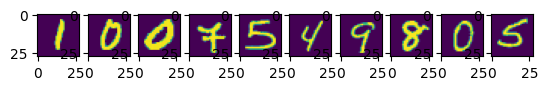

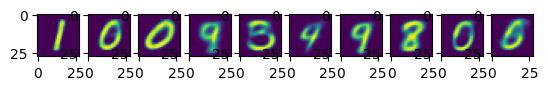

  3%|▎         | 1/30 [00:32<07:56, 16.45s/it, train reconst loss:=0.149, train disc loss:=0.971, train enc loss=1.45, test reconst loss:=0.149, test disc loss:=1.24, test enc loss=0.946]

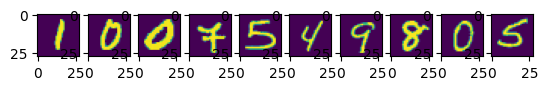

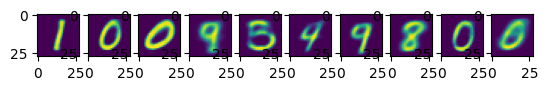

  7%|▋         | 2/30 [00:48<07:37, 16.35s/it, train reconst loss:=0.146, train disc loss:=0.839, train enc loss=1.78, test reconst loss:=0.145, test disc loss:=0.853, test enc loss=1.28]

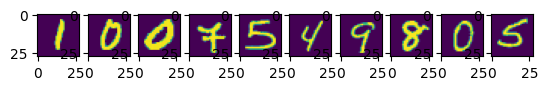

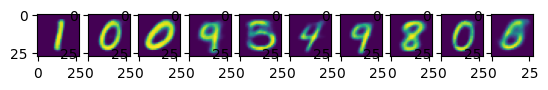

 10%|█         | 3/30 [01:04<07:17, 16.20s/it, train reconst loss:=0.144, train disc loss:=0.758, train enc loss=2.44, test reconst loss:=0.144, test disc loss:=0.739, test enc loss=1.44]

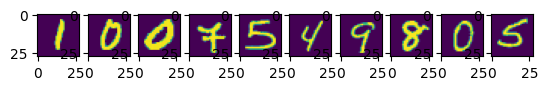

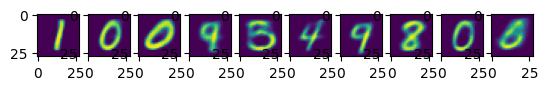

 13%|█▎        | 4/30 [01:20<07:02, 16.23s/it, train reconst loss:=0.142, train disc loss:=0.703, train enc loss=2.2, test reconst loss:=0.141, test disc loss:=0.524, test enc loss=1.66] 

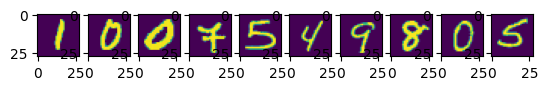

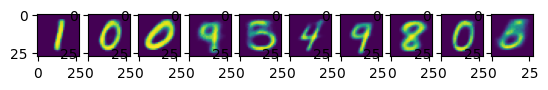

 17%|█▋        | 5/30 [01:36<06:46, 16.26s/it, train reconst loss:=0.141, train disc loss:=0.603, train enc loss=2.76, test reconst loss:=0.14, test disc loss:=0.474, test enc loss=1.84]

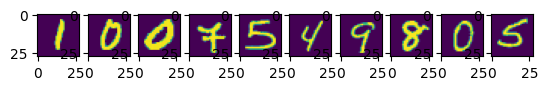

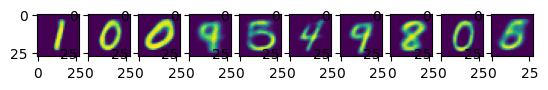

 20%|██        | 6/30 [01:53<06:30, 16.27s/it, train reconst loss:=0.139, train disc loss:=0.506, train enc loss=3.08, test reconst loss:=0.138, test disc loss:=0.361, test enc loss=2.02]

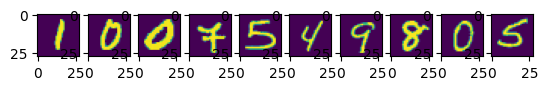

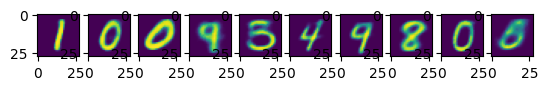

 23%|██▎       | 7/30 [02:09<06:14, 16.28s/it, train reconst loss:=0.138, train disc loss:=0.44, train enc loss=3.16, test reconst loss:=0.138, test disc loss:=0.578, test enc loss=1.84] 

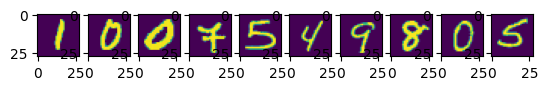

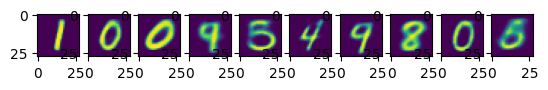

 27%|██▋       | 8/30 [02:25<05:57, 16.23s/it, train reconst loss:=0.137, train disc loss:=0.384, train enc loss=3.52, test reconst loss:=0.136, test disc loss:=0.272, test enc loss=2.56]

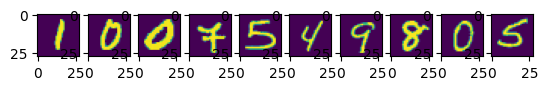

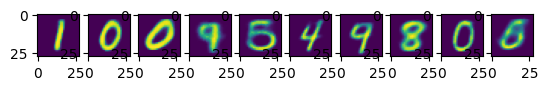

 30%|███       | 9/30 [02:41<05:40, 16.19s/it, train reconst loss:=0.135, train disc loss:=0.365, train enc loss=3.61, test reconst loss:=0.135, test disc loss:=0.457, test enc loss=2.16]

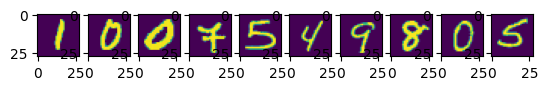

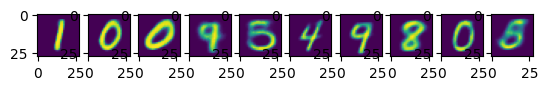

 33%|███▎      | 10/30 [02:58<05:26, 16.31s/it, train reconst loss:=0.134, train disc loss:=0.383, train enc loss=3.71, test reconst loss:=0.135, test disc loss:=0.553, test enc loss=1.99]

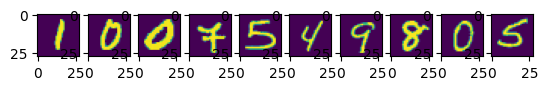

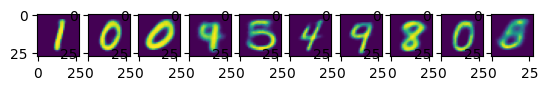

 37%|███▋      | 11/30 [03:14<05:08, 16.26s/it, train reconst loss:=0.132, train disc loss:=0.36, train enc loss=3.54, test reconst loss:=0.133, test disc loss:=0.268, test enc loss=2.6]  

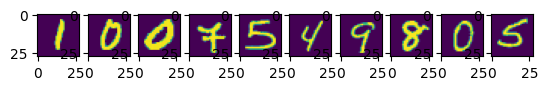

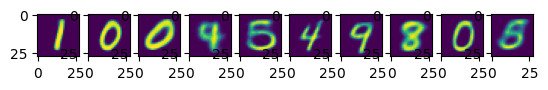

 40%|████      | 12/30 [03:30<04:52, 16.25s/it, train reconst loss:=0.131, train disc loss:=0.271, train enc loss=3.82, test reconst loss:=0.132, test disc loss:=0.337, test enc loss=3.01]

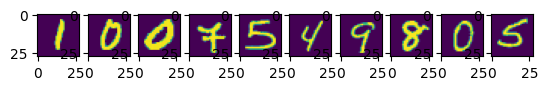

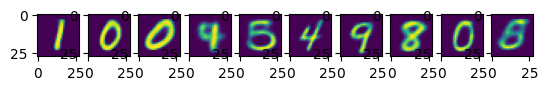

 43%|████▎     | 13/30 [03:47<04:36, 16.28s/it, train reconst loss:=0.131, train disc loss:=0.299, train enc loss=3.81, test reconst loss:=0.131, test disc loss:=0.404, test enc loss=2.68]

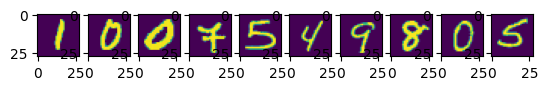

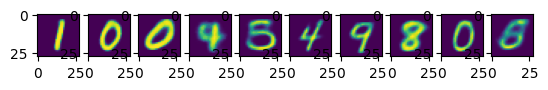

 47%|████▋     | 14/30 [04:03<04:20, 16.31s/it, train reconst loss:=0.13, train disc loss:=0.283, train enc loss=4.23, test reconst loss:=0.131, test disc loss:=0.314, test enc loss=2.84] 

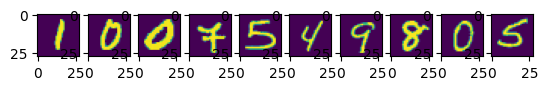

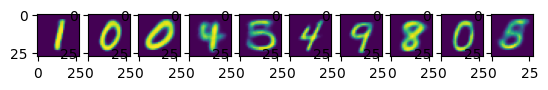

 50%|█████     | 15/30 [04:04<04:04, 16.28s/it, train reconst loss:=0.13, train disc loss:=0.283, train enc loss=4.23, test reconst loss:=0.131, test disc loss:=0.314, test enc loss=2.84]

In [ ]:
train_aae(dataloaders, models, optimizers, epochs, device)

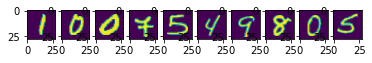

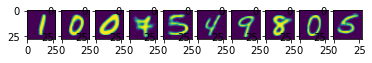

In [225]:
aae_encoder.eval()
aae_decoder.eval()
predictions = []
plots = 10
for i, data in enumerate(test_dataset):
    if i == plots:
        break
    pred = aae_decoder(aae_encoder(data[0].to(device).unsqueeze(0).view(1, 784)))
    predictions.append(pred.view(1, 28, 28).detach().cpu())
plotn(plots, test_dataset)
plotn(plots, predictions)

## 额外资料

* [NeuroHive上的博客文章](https://neurohive.io/ru/osnovy-data-science/variacionnyj-avtojenkoder-vae/)
* [变分自编码器解析](https://kvfrans.com/variational-autoencoders-explained/)



---

**免责声明**：  
本文档使用AI翻译服务[Co-op Translator](https://github.com/Azure/co-op-translator)进行翻译。尽管我们努力确保翻译的准确性，但请注意，自动翻译可能包含错误或不准确之处。原始语言的文档应被视为权威来源。对于关键信息，建议使用专业人工翻译。我们不对因使用此翻译而产生的任何误解或误读承担责任。
